In [43]:
import pandas as pd
import numpy as np

In [44]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [45]:
df_zero = df[df['diabetes'] == 0]
rows_to_drop = df_zero.sample(n=80000, random_state=42).index
df_new = df.drop(rows_to_drop)
print("Before:", df.shape)
print("After:", df_new.shape)
df_new.to_csv('cleaned_dataset.csv', index=False)

Before: (100000, 9)
After: (20000, 9)


In [50]:
df_new = df.drop(rows_to_drop)

In [51]:
df = df_new.copy()

In [52]:
df_new.to_csv('cleaned_dataset.csv', index=False)

In [53]:
df = pd.read_csv('cleaned_dataset.csv')

print(df.shape)

(20000, 9)


In [54]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
19995,Male,14.0,0,0,never,23.67,5.8,145,0
19996,Female,61.0,0,0,current,30.11,6.2,240,1
19997,Female,80.0,0,0,never,30.04,6.0,126,0
19998,Male,25.0,0,0,No Info,27.32,5.8,145,0
19999,Male,66.0,0,0,former,27.83,5.7,155,0


In [55]:
df.shape

(20000, 9)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               20000 non-null  object 
 1   age                  20000 non-null  float64
 2   hypertension         20000 non-null  int64  
 3   heart_disease        20000 non-null  int64  
 4   smoking_history      20000 non-null  object 
 5   bmi                  20000 non-null  float64
 6   HbA1c_level          20000 non-null  float64
 7   blood_glucose_level  20000 non-null  int64  
 8   diabetes             20000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 1.4+ MB


In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,20000.0,48.971970,21.938903,0.08,33.0000,52.00,66.00,80.00
hypertension,20000.0,0.140200,0.347203,0.00,0.0000,0.00,0.00,1.00
heart_disease,20000.0,0.080350,0.271841,0.00,0.0000,0.00,0.00,1.00
bmi,20000.0,29.051883,7.350150,10.21,25.3975,27.32,32.26,88.72
HbA1c_level,20000.0,6.050555,1.268671,3.50,5.7000,6.10,6.60,9.00
blood_glucose_level,20000.0,158.819100,55.241581,80.00,126.0000,155.00,160.00,300.00
diabetes,20000.0,0.425000,0.494355,0.00,0.0000,0.00,1.00,1.00


In [58]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [59]:
df.duplicated().sum()

np.int64(88)

In [60]:
df["diabetes"].value_counts()

,count
diabetes,
0,11500
1,8500


In [61]:
df["diabetes"].value_counts(normalize=True) * 100

,proportion
diabetes,
0,57.5
1,42.5


In [62]:
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
age,20000.0,48.971970,21.938903,0.08,33.0000,52.00,66.00,80.00
hypertension,20000.0,0.140200,0.347203,0.00,0.0000,0.00,0.00,1.00
heart_disease,20000.0,0.080350,0.271841,0.00,0.0000,0.00,0.00,1.00
bmi,20000.0,29.051883,7.350150,10.21,25.3975,27.32,32.26,88.72
HbA1c_level,20000.0,6.050555,1.268671,3.50,5.7000,6.10,6.60,9.00
blood_glucose_level,20000.0,158.819100,55.241581,80.00,126.0000,155.00,160.00,300.00
diabetes,20000.0,0.425000,0.494355,0.00,0.0000,0.00,1.00,1.00


In [63]:
categorical_cols = ["gender", "smoking_history"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for gender:
gender
Female    11263
Male       8736
Other         1
Name: count, dtype: int64

Value counts for smoking_history:
smoking_history
never          7330
No Info        5800
former         2547
current        1974
not current    1404
ever            945
Name: count, dtype: int64


In [64]:
print("Unique values in each column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values in each column:
gender : 3
age : 102
hypertension : 2
heart_disease : 2
smoking_history : 6
bmi : 3432
HbA1c_level : 18
blood_glucose_level : 18
diabetes : 2


In [65]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
print(numerical_cols)

Numerical columns:
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')


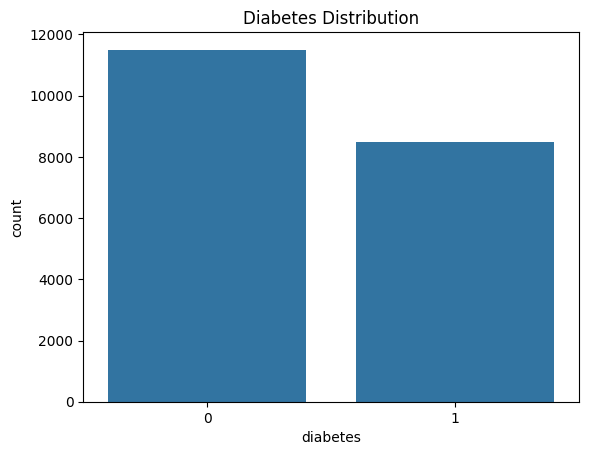

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="diabetes", data=df)
plt.title("Diabetes Distribution")
plt.show()

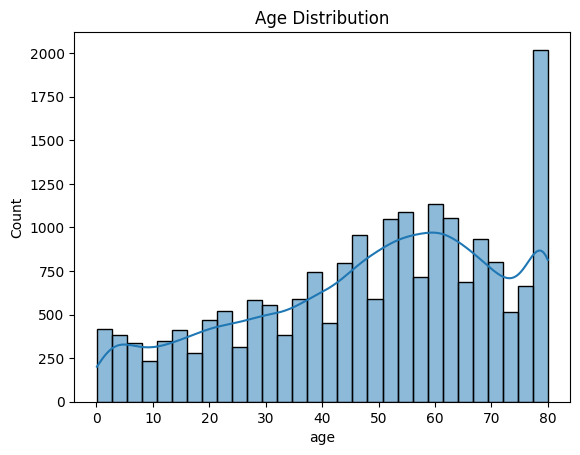

In [67]:
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

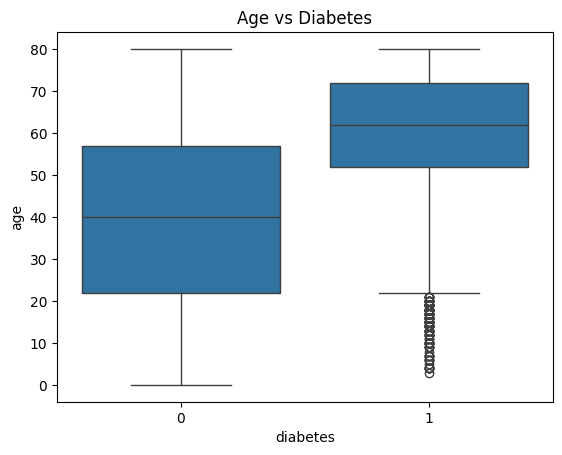

In [68]:
sns.boxplot(x="diabetes", y="age", data=df)
plt.title("Age vs Diabetes")
plt.show()

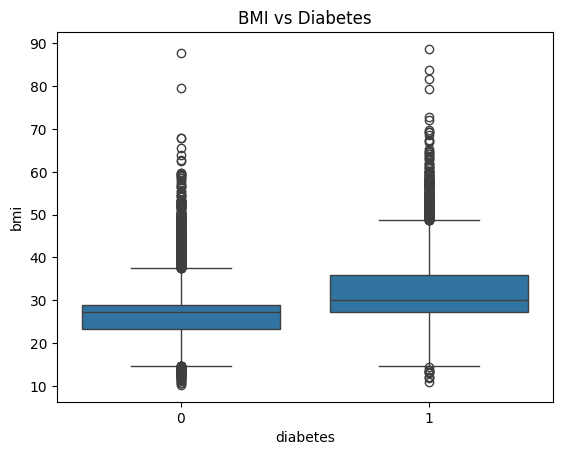

In [69]:
sns.boxplot(x="diabetes", y="bmi", data=df)
plt.title("BMI vs Diabetes")
plt.show()

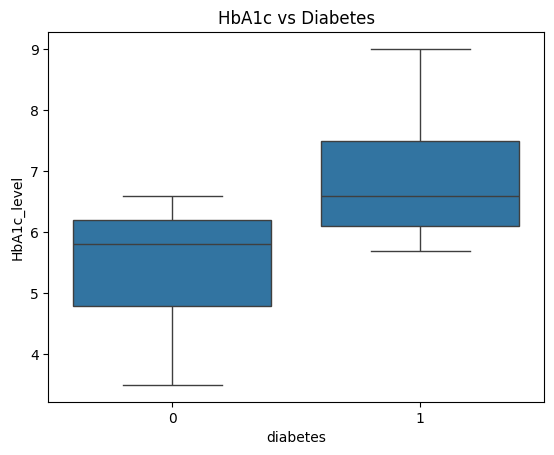

In [70]:
sns.boxplot(x="diabetes", y="HbA1c_level", data=df)
plt.title("HbA1c vs Diabetes")
plt.show()

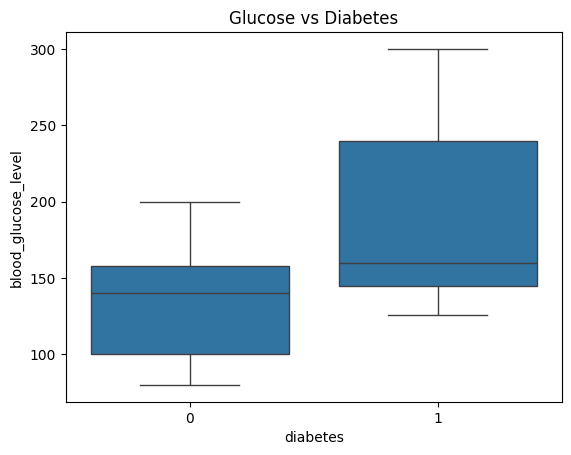

In [71]:
sns.boxplot(x="diabetes", y="blood_glucose_level", data=df)
plt.title("Glucose vs Diabetes")
plt.show()

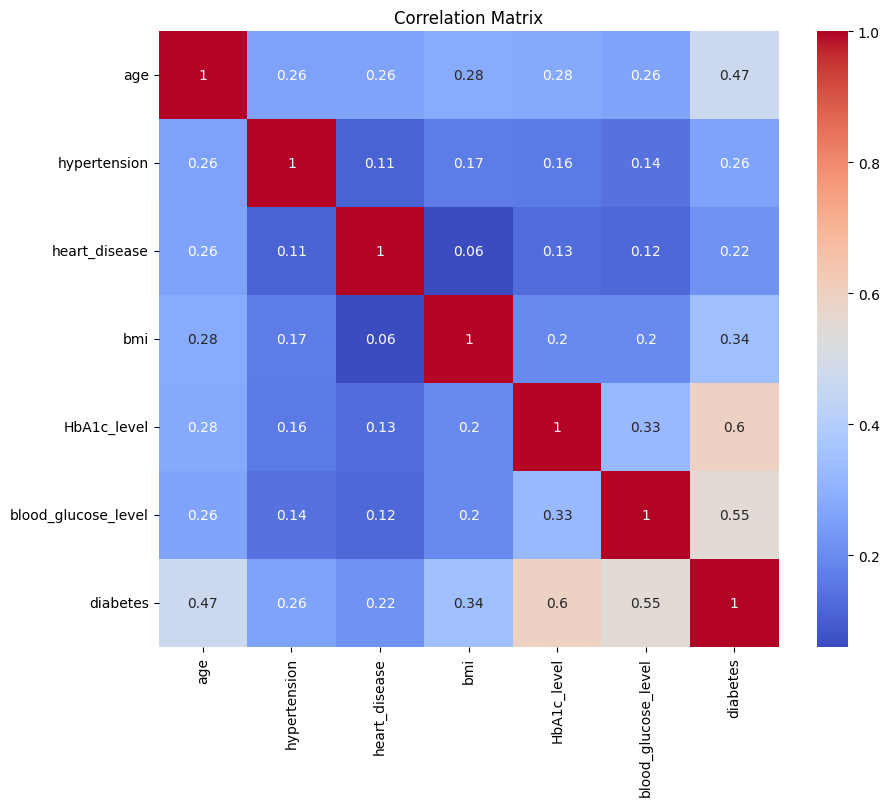

In [72]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

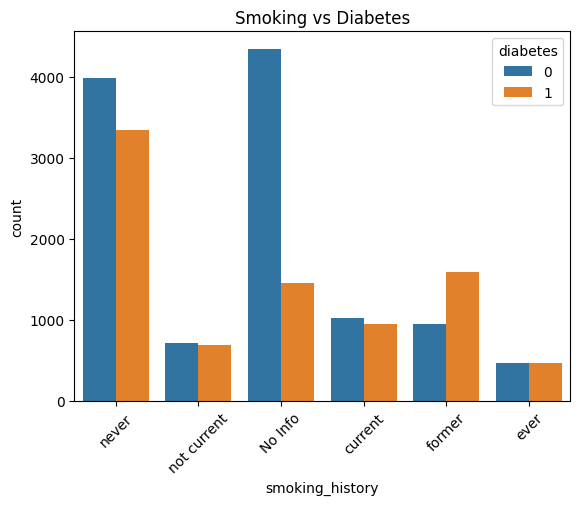

In [73]:
sns.countplot(x="smoking_history", hue="diabetes", data=df)
plt.xticks(rotation=45)
plt.title("Smoking vs Diabetes")
plt.show()

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["smoking_history"] = le.fit_transform(df["smoking_history"])

In [75]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [79]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )
}

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

results = []

for name, model in models.items():


    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, auc])

In [81]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "ROC-AUC"]
)

print(results_df.sort_values(by="ROC-AUC", ascending=False))

                 Model  Accuracy  Precision    Recall   ROC-AUC
2              XGBoost   0.91450   0.894767  0.905294  0.979557
1        Random Forest   0.90725   0.887012  0.895882  0.975586
0  Logistic Regression   0.88025   0.842785  0.882941  0.962773


In [82]:
xgb_model = models["XGBoost"]

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

               Feature  Importance
6          HbA1c_level    0.463196
7  blood_glucose_level    0.271558
1                  age    0.080413
2         hypertension    0.066746
3        heart_disease    0.054929
5                  bmi    0.031066
4      smoking_history    0.017281
0               gender    0.014811


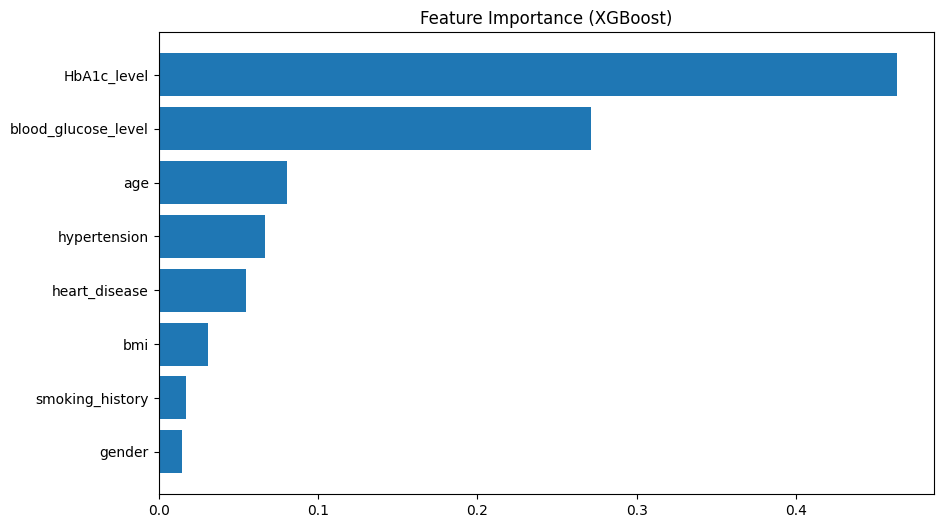

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.show()